In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.rcParams["font.family"] = ["Noto Sans", "Noto Sans CJK JP"]
plt.rcParams["axes.unicode_minus"] = False

print("라이브러리 불러오기 완료")

Matplotlib is building the font cache; this may take a moment.


라이브러리 불러오기 완료


In [4]:
DATA_PATH = Path("data/stock_data.csv")

df = pd.read_csv(DATA_PATH)

print("=== 데이터 크기 ===")
print(f"행 수: {df.shape[0]:,}")
print(f"열 수: {df.shape[1]}")
print()

print("=== 컬럼 ===")
print(df.columns.tolist())

print("\n=== 데이터 처음 5개 ===")
display(df.head())

=== 데이터 크기 ===
행 수: 1,254
열 수: 6

=== 컬럼 ===
['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']

=== 데이터 처음 5개 ===


,Date,Close/Last,Volume,Open,High,Low
0,08/21/2026,$214.72,98869300,$218.42,$218.74,$214.50
1,08/20/2026,$216.85,92457040,$218.36,$219.86,$215.66
2,08/19/2026,$217.56,96797310,$221.67,$222.87,$216.76
3,08/18/2026,$219.74,103128200,$220.45,$221.64,$218.6902
4,08/17/2026,$225.01,93678690,$225.98,$227.92,$224.86


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

print("=== 데이터 기간 ===")
print(f"시작일: {df['Date'].min().date()}")
print(f"종료일: {df['Date'].max().date()}")

print("\n=== 데이터 타입 ===")
print(df.dtypes)

print("\n=== 데이터 마지막 5개 ===")
display(df.tail())

=== 데이터 기간 ===
시작일: 2021-08-24
종료일: 2026-08-21

=== 데이터 타입 ===
Date          datetime64[us]
Close/Last               str
Volume                 int64
Open                     str
High                     str
Low                      str
dtype: object

=== 데이터 마지막 5개 ===


,Date,Close/Last,Volume,Open,High,Low
1249,2021-08-30,$22.688,262579900,$22.83,$23.043,$22.551
1250,2021-08-27,$22.636,304722200,$22.184,$22.722,$22.167
1251,2021-08-26,$22.068,237940400,$22.20,$22.34,$21.79
1252,2021-08-25,$22.213,347701000,$21.737,$22.47,$21.722
1253,2021-08-24,$21.793,297298900,$21.753,$21.959,$21.535


In [6]:
price_columns = ["Close/Last", "Open", "High", "Low"]

for column in price_columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

df["Volume"] = pd.to_numeric(df["Volume"], errors="coerce")

# 날짜 기준으로 오래된 날짜 → 최신 날짜 순서로 정렬
df = df.sort_values("Date").reset_index(drop=True)

print("=== 정제 후 데이터 타입 ===")
print(df.dtypes)

print("\n=== 정제 후 데이터 ===")
display(df.head())

print("\n=== 마지막 데이터 ===")
display(df.tail())

=== 정제 후 데이터 타입 ===
Date          datetime64[us]
Close/Last           float64
Volume                 int64
Open                 float64
High                 float64
Low                  float64
dtype: object

=== 정제 후 데이터 ===


,Date,Close/Last,Volume,Open,High,Low
0,2021-08-24,21.793,297298900,21.753,21.959,21.535
1,2021-08-25,22.213,347701000,21.737,22.470,21.722
2,2021-08-26,22.068,237940400,22.200,22.340,21.790
3,2021-08-27,22.636,304722200,22.184,22.722,22.167
4,2021-08-30,22.688,262579900,22.830,23.043,22.551



=== 마지막 데이터 ===


,Date,Close/Last,Volume,Open,High,Low
1249,2026-08-17,225.01,93678690,225.98,227.92,224.8600
1250,2026-08-18,219.74,103128200,220.45,221.64,218.6902
1251,2026-08-19,217.56,96797310,221.67,222.87,216.7600
1252,2026-08-20,216.85,92457040,218.36,219.86,215.6600
1253,2026-08-21,214.72,98869300,218.42,218.74,214.5000


In [7]:
print("=== 결측치 ===")
print(df.isnull().sum())

print("\n=== 결측치가 있는 행 수 ===")
print(df.isnull().any(axis=1).sum())

print("\n=== 중복 날짜 ===")
duplicate_dates = df["Date"].duplicated().sum()
print(f"중복 날짜: {duplicate_dates}개")

=== 결측치 ===
Date          0
Close/Last    0
Volume        0
Open          0
High          0
Low           0
dtype: int64

=== 결측치가 있는 행 수 ===
0

=== 중복 날짜 ===
중복 날짜: 0개


In [8]:
print("=== High < Low 확인 ===")
high_low_error = (df["High"] < df["Low"]).sum()
print(f"{high_low_error}건")

print("\n=== Open/Close가 High보다 큰 경우 ===")
high_error = ((df["Open"] > df["High"]) | (df["Close/Last"] > df["High"])).sum()
print(f"{high_error}건")

print("\n=== Open/Close가 Low보다 작은 경우 ===")
low_error = ((df["Open"] < df["Low"]) | (df["Close/Last"] < df["Low"])).sum()
print(f"{low_error}건")

=== High < Low 확인 ===
0건

=== Open/Close가 High보다 큰 경우 ===
0건

=== Open/Close가 Low보다 작은 경우 ===
0건


In [9]:
print("=== 가격 데이터 기본 통계 ===")
display(
    df[["Close/Last", "Open", "High", "Low"]].describe()
)

print("\n=== 거래량 기본 통계 ===")
display(df[["Volume"]].describe())

=== 가격 데이터 기본 통계 ===


,Close/Last,Open,High,Low
count,1254.000000,1254.000000,1254.000000,1254.000000
mean,90.500365,90.528888,91.999344,88.895580
std,68.108809,68.193195,69.090188,67.120459
min,11.227000,10.971000,11.735000,10.813000
25%,24.719750,24.818750,25.269250,24.021750
50%,75.050000,74.562500,76.593000,73.360500
75%,144.080000,143.840000,145.687500,141.832500
max,235.740000,229.870000,236.540000,229.300000



=== 거래량 기본 통계 ===


,Volume
count,1.254000e+03
mean,3.700383e+08
std,1.918488e+08
min,6.552855e+07
25%,1.987901e+08
50%,3.561786e+08
75%,4.911216e+08
max,1.543911e+09


In [10]:
date_diff = df["Date"].diff().dt.days

print("=== 날짜 간격 ===")
print(date_diff.value_counts().sort_index())

print("\n=== 3일 이상 차이가 나는 구간 ===")

large_gaps = pd.DataFrame({
    "Date": df["Date"],
    "days_since_previous": date_diff
})

large_gaps = large_gaps[large_gaps["days_since_previous"] >= 3]

display(large_gaps)

=== 날짜 간격 ===
Date
1.0    979
2.0     14
3.0    224
4.0     36
Name: count, dtype: int64

=== 3일 이상 차이가 나는 구간 ===


,Date,days_since_previous
4,2021-08-30,3.0
9,2021-09-07,4.0
13,2021-09-13,3.0
18,2021-09-20,3.0
23,2021-09-27,3.0
...,...,...
1229,2026-07-20,3.0
1234,2026-07-27,3.0
1239,2026-08-03,3.0
1244,2026-08-10,3.0


In [11]:
df["MA20"] = df["Close/Last"].rolling(window=20).mean()
df["MA50"] = df["Close/Last"].rolling(window=50).mean()

display(
    df[["Date", "Close/Last", "MA20", "MA50"]].tail()
)

,Date,Close/Last,MA20,MA50
1249,2026-08-17,225.01,211.4815,206.6466
1250,2026-08-18,219.74,212.1040,206.9394
1251,2026-08-19,217.56,212.3790,207.1178
1252,2026-08-20,216.85,212.7835,207.2910
1253,2026-08-21,214.72,213.1775,207.5770


findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sa

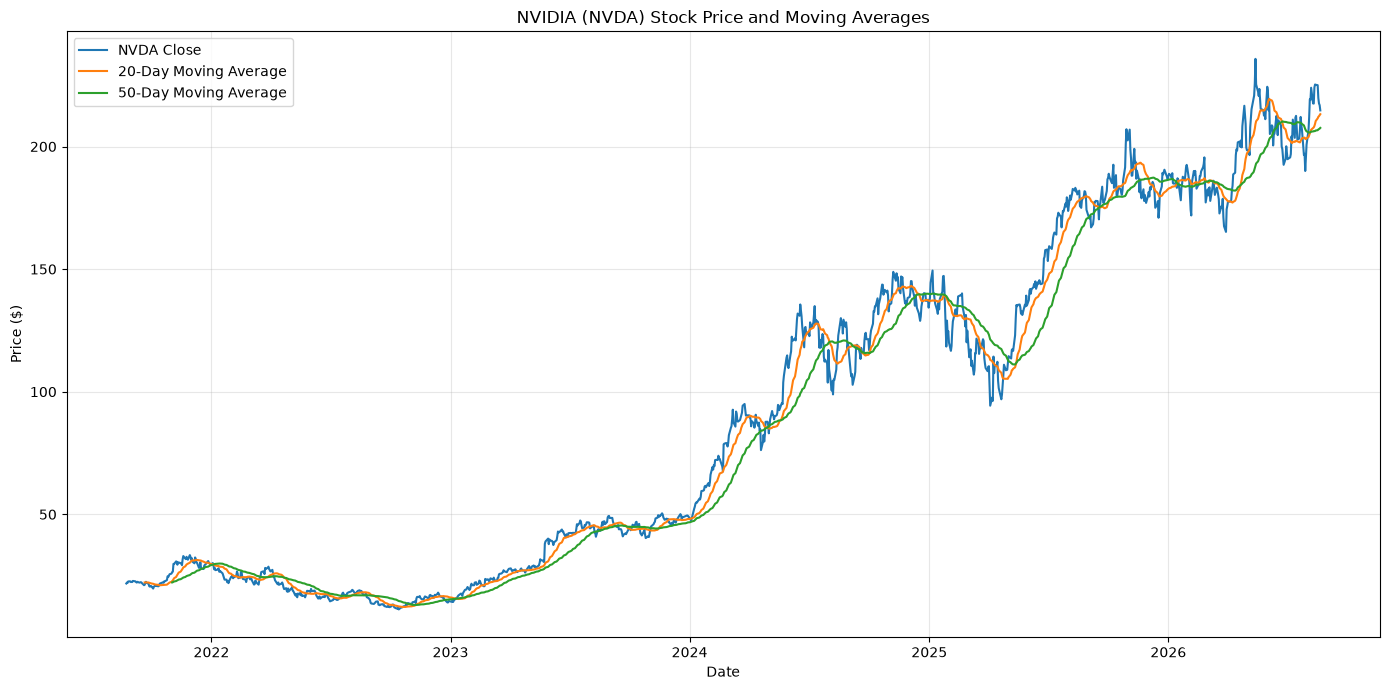

In [12]:
plt.figure(figsize=(14, 7))

plt.plot(
    df["Date"],
    df["Close/Last"],
    label="NVDA Close"
)

plt.plot(
    df["Date"],
    df["MA20"],
    label="20-Day Moving Average"
)

plt.plot(
    df["Date"],
    df["MA50"],
    label="50-Day Moving Average"
)

plt.title("NVIDIA (NVDA) Stock Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/01_price_moving_average.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [13]:
df["Daily_Return"] = (
    df["Close/Last"].pct_change() * 100
)

print("=== 일별 수익률 기본 통계 ===")
display(df["Daily_Return"].describe())

print("\n=== 일별 수익률 데이터 ===")
display(
    df[["Date", "Close/Last", "Daily_Return"]].head()
)

=== 일별 수익률 기본 통계 ===


count    1253.000000
mean        0.235434
std         3.264669
min       -16.968167
25%        -1.619433
50%         0.254440
75%         2.012542
max        24.369638
Name: Daily_Return, dtype: float64


=== 일별 수익률 데이터 ===


,Date,Close/Last,Daily_Return
0,2021-08-24,21.793,NaN
1,2021-08-25,22.213,1.927224
2,2021-08-26,22.068,-0.652771
3,2021-08-27,22.636,2.573863
4,2021-08-30,22.688,0.229723


In [14]:
top_rise = (
    df.nlargest(5, "Daily_Return")
    [["Date", "Close/Last", "Daily_Return"]]
)

top_fall = (
    df.nsmallest(5, "Daily_Return")
    [["Date", "Close/Last", "Daily_Return"]]
)

print("=== 가장 큰 상승 Top 5 ===")
display(top_rise)

print("\n=== 가장 큰 하락 Top 5 ===")
display(top_fall)

=== 가장 큰 상승 Top 5 ===


,Date,Close/Last,Daily_Return
441,2023-05-25,37.980,24.369638
910,2025-04-09,114.330,18.722741
627,2024-02-22,78.538,16.400877
307,2022-11-10,15.750,14.329268
377,2023-02-23,23.664,14.021393



=== 가장 큰 하락 Top 5 ===


,Date,Close/Last,Daily_Return
859,2025-01-27,118.420,-16.968167
667,2024-04-19,76.200,-10.004606
760,2024-09-03,108.000,-9.525006
265,2022-09-13,13.131,-9.472596
178,2022-05-09,16.950,-9.236948


findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sa

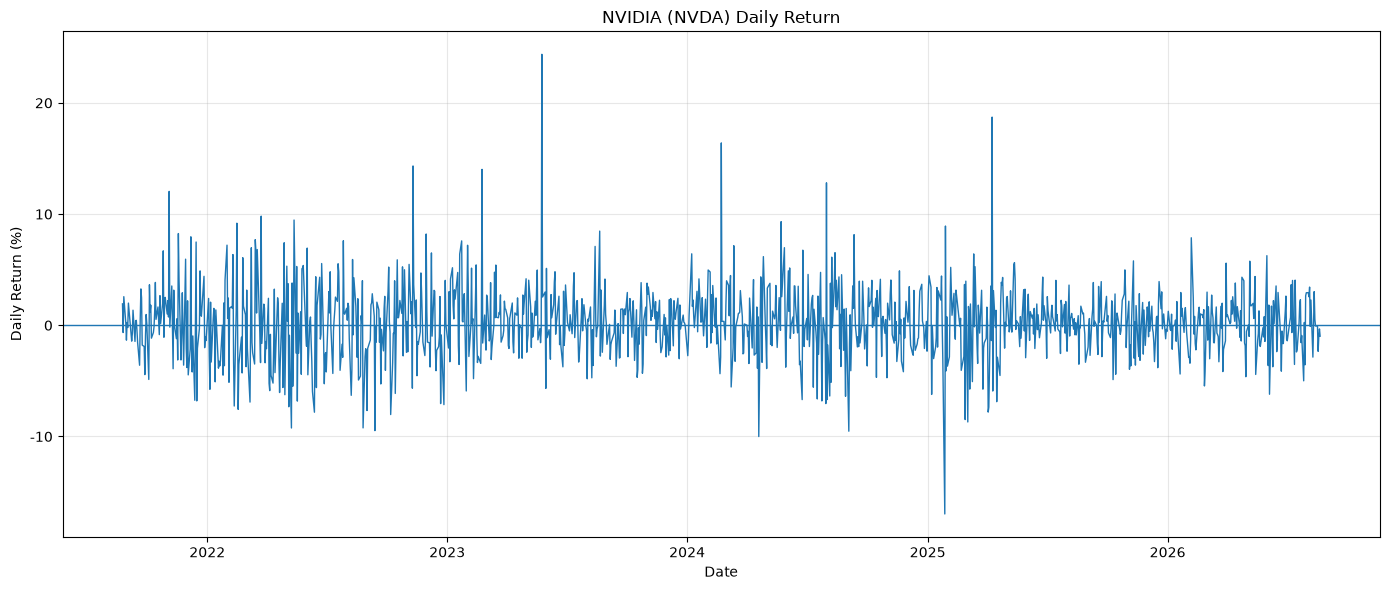

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Daily_Return"],
    linewidth=1
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("NVIDIA (NVDA) Daily Return")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/02_daily_return.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [16]:
df["Rolling_Volatility"] = (
    df["Daily_Return"]
    .rolling(window=20)
    .std()
)

print("=== Rolling Volatility 기본 통계 ===")
display(df["Rolling_Volatility"].describe())

print("\n=== 변동성이 높은 구간 Top 10 ===")

high_volatility = (
    df.nlargest(10, "Rolling_Volatility")
    [["Date", "Daily_Return", "Rolling_Volatility"]]
)

display(high_volatility)

=== Rolling Volatility 기본 통계 ===


count    1234.000000
mean        3.101648
std         1.095210
min         1.394949
25%         2.218305
50%         2.852016
75%         3.868224
max         6.016186
Name: Rolling_Volatility, dtype: float64


=== 변동성이 높은 구간 Top 10 ===


,Date,Daily_Return,Rolling_Volatility
455,2023-06-15,-0.800056,6.016186
450,2023-06-08,2.761841,5.999593
449,2023-06-07,-3.050137,5.994181
454,2023-06-14,4.814490,5.989203
460,2023-06-23,-1.896572,5.984561
456,2023-06-16,0.091436,5.983920
458,2023-06-21,-1.741691,5.982298
451,2023-06-09,0.675149,5.971498
453,2023-06-13,3.900512,5.959878
448,2023-06-06,-1.319854,5.956215


findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sa

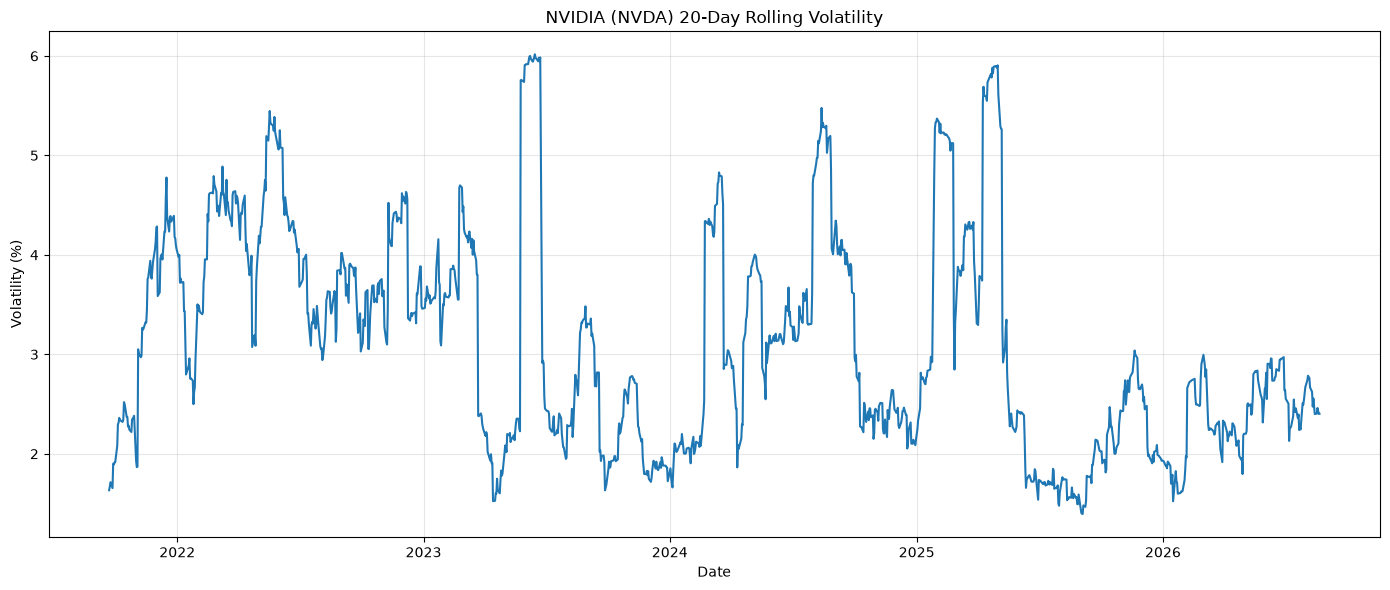

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Rolling_Volatility"]
)

plt.title("NVIDIA (NVDA) 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/03_volatility.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [18]:
major_moves = pd.concat([
    df.nlargest(5, "Daily_Return"),
    df.nsmallest(5, "Daily_Return")
])

major_moves = (
    major_moves[
        ["Date", "Close/Last", "Daily_Return", "Rolling_Volatility"]
    ]
    .drop_duplicates()
    .sort_values("Date")
)

print("=== 주요 가격 변동 구간 ===")
display(major_moves)

=== 주요 가격 변동 구간 ===


,Date,Close/Last,Daily_Return,Rolling_Volatility
178,2022-05-09,16.950,-9.236948,4.593806
265,2022-09-13,13.131,-9.472596,3.897374
307,2022-11-10,15.750,14.329268,4.522652
377,2023-02-23,23.664,14.021393,4.671898
441,2023-05-25,37.980,24.369638,5.755701
627,2024-02-22,78.538,16.400877,4.338554
667,2024-04-19,76.200,-10.004606,3.121346
760,2024-09-03,108.000,-9.525006,4.344154
859,2025-01-27,118.420,-16.968167,4.813805
910,2025-04-09,114.330,18.722741,5.530106


In [19]:
events = pd.DataFrame({
    "Date": pd.to_datetime([
        "2023-05-25",
        "2024-02-22",
        "2025-01-27",
        "2025-04-09"
    ]),
    "Event": [
        "2023 Q1 Earnings / AI demand",
        "2024 Q4 Earnings / AI demand",
        "DeepSeek shock",
        "US tariff / market volatility"
    ]
})

events

,Date,Event
0,2023-05-25,2023 Q1 Earnings / AI demand
1,2024-02-22,2024 Q4 Earnings / AI demand
2,2025-01-27,DeepSeek shock
3,2025-04-09,US tariff / market volatility


findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sa

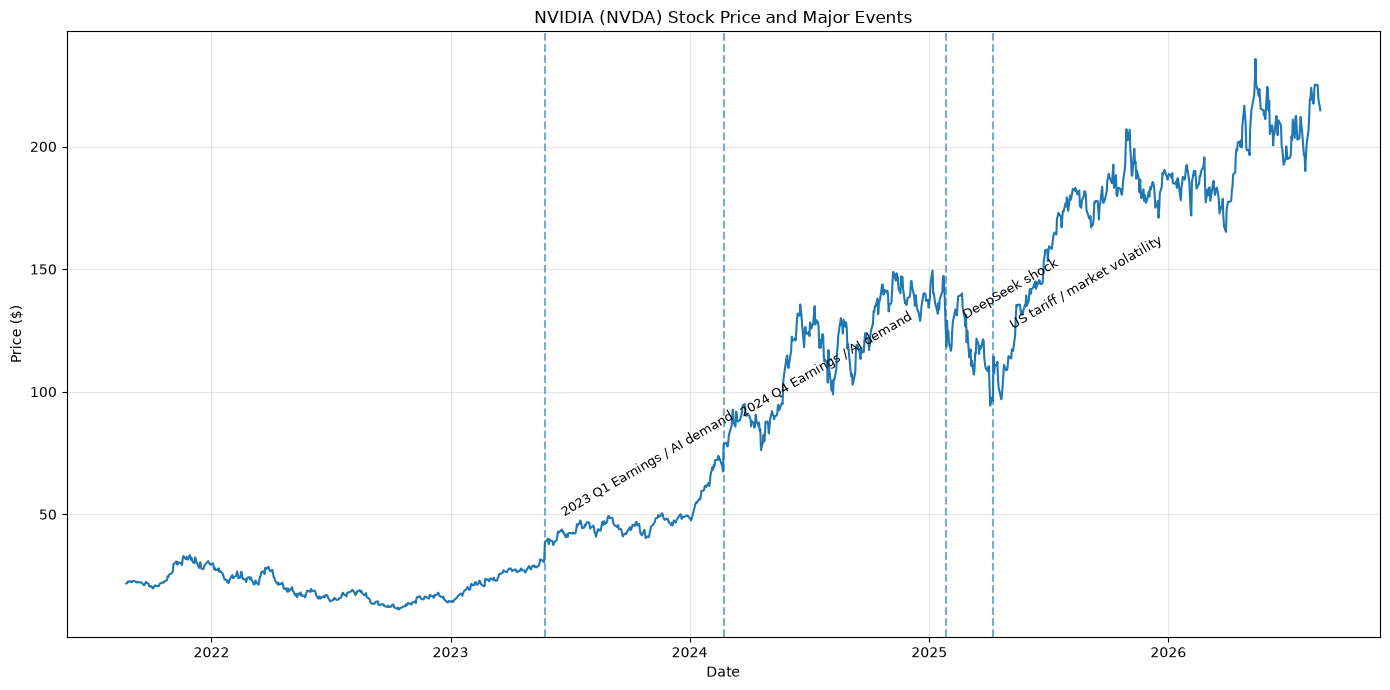

In [20]:
plt.figure(figsize=(14, 7))

plt.plot(
    df["Date"],
    df["Close/Last"],
    label="NVDA Close"
)

for _, event in events.iterrows():
    event_date = event["Date"]

    nearest = df.iloc[
        (df["Date"] - event_date).abs().argsort()[:1]
    ]

    event_price = nearest["Close/Last"].iloc[0]

    plt.axvline(
        event_date,
        linestyle="--",
        alpha=0.6
    )

    plt.annotate(
        event["Event"],
        xy=(event_date, event_price),
        xytext=(10, 20),
        textcoords="offset points",
        rotation=30,
        fontsize=9
    )

plt.title("NVIDIA (NVDA) Stock Price and Major Events")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/04_major_events.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [21]:
print("========================================")
print("       NVDA 시계열 분석 결과 요약")
print("========================================")

print(f"\n분석 기간: {df['Date'].min().date()} ~ {df['Date'].max().date()}")
print(f"데이터 포인트: {len(df):,}개")

max_rise = df.loc[df["Daily_Return"].idxmax()]
max_fall = df.loc[df["Daily_Return"].idxmin()]
max_vol = df.loc[df["Rolling_Volatility"].idxmax()]

print("\n[최대 상승]")
print(
    f"{max_rise['Date'].date()} / "
    f"{max_rise['Daily_Return']:.2f}%"
)

print("\n[최대 하락]")
print(
    f"{max_fall['Date'].date()} / "
    f"{max_fall['Daily_Return']:.2f}%"
)

print("\n[최대 변동성]")
print(
    f"{max_vol['Date'].date()} / "
    f"{max_vol['Rolling_Volatility']:.2f}%"
)

print("\n[생성된 시각화]")
print("1. 주가 + 이동평균")
print("2. 일별 수익률")
print("3. 20일 Rolling Volatility")
print("4. 주요 이벤트와 주가")

       NVDA 시계열 분석 결과 요약

분석 기간: 2021-08-24 ~ 2026-08-21
데이터 포인트: 1,254개

[최대 상승]
2023-05-25 / 24.37%

[최대 하락]
2025-01-27 / -16.97%

[최대 변동성]
2023-06-15 / 6.02%

[생성된 시각화]
1. 주가 + 이동평균
2. 일별 수익률
3. 20일 Rolling Volatility
4. 주요 이벤트와 주가
